# Diabetic Retinopathy Detection — ConvNeXt-Base (Transfer Learning)
## Computer Vision Project — UC3M

This notebook fine-tunes **ConvNeXt-Base** pretrained on ImageNet-22K for binary Diabetic Retinopathy (DR) detection.

**Task:** Binary classification — No DR (label 0) vs. DR present (label 1)  
**Evaluation metric:** ROC-AUC  
**Strategy:** Partial fine-tuning (last feature stage + classifier) with Focal Loss and weighted sampling  
**Best validation AUC achieved:** 0.8031 | Accuracy: 0.7620

## 1. Imports and Configuration

Standard deep learning libraries are imported:
- **PyTorch + torchvision**: model training, pretrained weights, and standard transforms
- **skimage / OpenCV**: image I/O and domain-specific preprocessing
- **scikit-learn**: evaluation metrics (ROC-AUC, accuracy, ROC curve)
- **tqdm**: progress bars during training

A fixed random seed (`seed=42`) is applied across Python, NumPy, and PyTorch to ensure full reproducibility. The device is automatically set to GPU (`cuda:0`) when available, falling back to CPU.

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

from torchvision.models import convnext_base, ConvNeXt_Base_Weights

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset — `RetinopathyDataset`

A custom PyTorch `Dataset` loads images and labels from a CSV file. Key design decisions:

- **Right-eye normalization:** fundus images are taken of both eyes. Since the optic disc (a key anatomical landmark for DR grading) appears on opposite sides in left vs. right eyes, right-eye images (`eye == 1`) are horizontally flipped so that anatomy is consistently oriented across the full dataset. This prevents the model from learning spurious left/right asymmetry.
- **Binary label conversion:** the original 0–4 severity scale (No DR, Mild, Moderate, Severe, Proliferative DR) is collapsed into a binary problem: `label > 0` → DR-positive. This simplification makes the task tractable with our 2000-image training set and is aligned with the CodaBench evaluation protocol.
- **Optional size cap (`maxSize`):** allows training on a random subset for debugging, using a seeded permutation for reproducibility.

In [3]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Custom Preprocessing Transforms

A fully custom transform pipeline is implemented using PyTorch's callable-object convention, because fundus images require domain-specific preprocessing unavailable in standard torchvision transforms.

### `CropByEye`
Fundus photographs typically have large black borders outside the circular retinal region (an artifact of the fundus camera optics). This transform applies OpenCV binary thresholding on the grayscale image to generate a foreground mask and crops tightly to the bounding box of the detected eye region. This removes uninformative background pixels, ensures the model focuses on retinal tissue, and standardizes the spatial input across different imaging setups. A small border margin avoids accidentally clipping retinal edges.

### `Rescale`
Proportionally resizes the (potentially non-square) cropped image so that the shorter side reaches the target size. Preserving aspect ratio avoids distorting the retinal geometry before the final center crop.

### `ToTensor`
Transposes the H×W×C NumPy array (float32 in [0,1]) to C×H×W format and wraps it as a PyTorch tensor, as required by PyTorch convolution layers.

In [4]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Augmentation is applied **only during training** to increase effective dataset diversity and reduce overfitting. The chosen augmentations reflect realistic variability in clinical fundus photography:

- **Random horizontal flip (p=0.5):** valid because both eyes are already normalized to the same orientation via the right-eye mirroring in `RetinopathyDataset`. Horizontal flips do not alter clinical meaningfulness.
- **Random rotation (±10°):** fundus cameras may be slightly rotated relative to the patient's eye axis — small rotations simulate this natural variability without introducing implausible distortions.
- **Color jitter (brightness ±0.2, contrast ±0.2):** different fundus cameras and imaging environments produce varying illumination and contrast. Mild photometric perturbation makes the model robust to these equipment-level differences.

`TVAugment` wraps `torchvision.transforms` and integrates them into our custom dictionary-based pipeline.

In [5]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [6]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [7]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [8]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [9]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

## 5. Transform Pipelines

Two separate pipelines are defined:

- **`train_transform`:** includes random augmentation (flip, rotation, color jitter) applied after eye cropping and resizing — used only during training
- **`val_transform`:** fully deterministic — only crop, resize, center crop, and normalize — used for validation, testing, and final prediction to guarantee consistent, reproducible outputs

Both pipelines apply **ImageNet normalization** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`). This is standard practice when fine-tuning ImageNet-pretrained models: it aligns the input distribution of our fundus images with the distribution the pretrained weights were optimized for.

In [10]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVAugment(),
    CenterCrop(256),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(256),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## 6. Data Loaders

Three `DataLoader` instances are created for training, validation, and test splits:
- **Train:** `batch_size=32`, `shuffle=True` — shuffling prevents the model from memorizing sample ordering across epochs
- **Val / Test:** `batch_size=64`, `shuffle=False` — deterministic order ensures consistent epoch-level evaluation

**Class imbalance note:** the training set contains ~1468 negative (No DR) and ~532 positive (DR) samples (~73% vs ~27%). Without correction, a model could achieve 73% accuracy by predicting the majority class. Some models address this with `WeightedRandomSampler` in the next cell.

In [11]:
data_dir = "/content/drive/MyDrive/CV_b/Project_2/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)



## 7. Addressing Class Imbalance — Weighted Random Sampling

The training set is heavily skewed (~73% No DR, ~27% DR). `WeightedRandomSampler` addresses this by assigning each training sample a weight inversely proportional to its class frequency. Samples are drawn according to these weights during each epoch, so both classes appear roughly equally often in each training batch.

This technique is preferable to manual oversampling because:
- It does not duplicate or alter images in the dataset
- It leverages PyTorch's efficient built-in sampling infrastructure
- The reweighting can be changed without touching the underlying dataset

The class counts are printed to verify the imbalance quantitatively before applying the fix.

In [12]:
from torch.utils.data import WeightedRandomSampler

# Obtener labels
labels = train_dataset.dataset['label'].values
labels = (labels > 0).astype(int)

# Contar clases
class_counts = np.bincount(labels)
print("Class counts:", class_counts)

# Invertir frecuencia
class_weights = 1. / class_counts

# Asignar peso a cada sample
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Class counts: [1468  532]


## 8. Model Architecture — ConvNeXt-Base (Fine-Tuning)

**ConvNeXt-Base** (Liu et al., 2022) is a modern pure-convolutional architecture that achieves Vision Transformer-level performance while maintaining the simplicity and efficiency of CNNs. It adopts transformer-inspired design choices: depthwise convolutions with large kernels (7×7), inverted bottleneck blocks, GELU activation, and Layer Normalization instead of Batch Normalization. Pretrained on ImageNet-22K (14M images, 22K classes) for richer representations.

**Architecture adaptation:**
- The final classification layer (`classifier[2]`) is replaced with a single linear unit for binary output
- **Partial fine-tuning strategy:** all backbone layers are frozen; only the last feature stage (`features[-1]`) and the classifier are trained. This preserves powerful low-level features from the large ImageNet-22K pretraining while efficiently adapting high-level semantics to the DR domain — critical for avoiding overfitting with 2000 training images.

In [13]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

In [14]:
weights = ConvNeXt_Base_Weights.DEFAULT
model = convnext_base(weights=weights)

# Cambiar la cabeza (classifier)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, 1)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 190MB/s]


## 9. Loss Function — Focal Loss

Standard Binary Cross-Entropy (BCE) can be suboptimal for imbalanced datasets: the model quickly learns to assign high confidence to the dominant class, reducing the loss without genuinely learning the minority class.

**Focal Loss** (Lin et al., 2017) modifies BCE by adding a modulating factor `(1 − p_t)^γ` that down-weights easy (confidently correct) examples and focuses the gradient signal on hard misclassifications:

```
FL(p_t) = α · (1 − p_t)^γ · BCE(p_t)
```

- **`alpha=0.5`:** balancing factor for positive vs. negative class contributions
- **`gamma=1.5`:** focusing exponent — higher values suppress easy examples more aggressively; 1.5 is a moderate choice that avoids over-correcting while still improving hard-case learning

Focal Loss is used here in combination with `WeightedRandomSampler`, providing a dual approach to handling class imbalance.

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=1.5):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        probs = torch.sigmoid(inputs)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma

        loss = focal_weight * bce_loss
        return loss.mean()

## 9. Loss Function, Optimizer, and Scheduler

- **Loss:** `FocalLoss` (α=0.5, γ=1.5) — down-weights easy examples and focuses training on hard boundary cases, complementing the weighted sampler for handling class imbalance
- **Optimizer:** `AdamW` with `lr=3e-5` — AdamW's decoupled weight decay improves generalization; the very small learning rate avoids corrupting pretrained ImageNet-22K representations
- **Scheduler:** `CosineAnnealingLR` (T_max=10) smoothly reduces the learning rate following a cosine curve within each 10-epoch cycle, allowing the model to explore the loss landscape broadly early and converge precisely near the minimum

In [16]:
criterion = FocalLoss(alpha=0.5, gamma=1.5)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5
)

scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

## 11. Training Loop with Early Stopping

The `train_model` function implements the full training procedure with early stopping. Key design decisions:

- **Primary metric: ROC-AUC** — used instead of accuracy because it is threshold-independent and handles class imbalance robustly. A naive majority-class predictor achieves ~73% accuracy but only AUC ~0.5, making AUC a far more informative signal.
- **Early stopping (patience=10):** training halts if validation AUC does not improve for 10 consecutive epochs, preventing overfitting and avoiding unnecessary GPU compute.
- **Best-model checkpointing:** model weights achieving the highest validation AUC are saved to disk after every improvement and restored at the end of training. This ensures the returned model is the global best — not just the final epoch.
- **LR scheduler step:** called at the end of each epoch to decay the learning rate according to the chosen schedule, enabling fine-grained convergence near the optimum.

In [17]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "/content/drive/MyDrive/best_model_convx.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 10. Selective Layer Unfreezing (Partial Fine-Tuning)

We adopt a **partial fine-tuning** strategy: first all backbone parameters are frozen, then only the most task-relevant layers are selectively unfrozen before training.

**Rationale:**
- With only 2000 training images, fine-tuning all layers risks **catastrophic forgetting** — overwriting the rich general visual features learned on ImageNet with noisy gradients from a small medical dataset
- Early convolutional layers capture low-level features (edges, textures, color gradients) that are equally useful for medical images
- Later layers capture high-level semantic features that are more dataset-specific and need to be adapted for DR grading
- Only unfreezing the final feature stage and classifier provides the best trade-off between adaptation and regularization

In [18]:
# Freeze todo
for param in model.parameters():
    param.requires_grad = False

# Unfreeze últimas capas del backbone
for param in model.features[-1].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

## 12. Training

The model is trained by calling `train_model`. The function returns the best model (by validation AUC), along with per-epoch training/validation losses and validation AUC values. These are plotted below to diagnose convergence:
- A decreasing training loss with stable validation loss → healthy learning
- A diverging gap between train and val loss → overfitting (check augmentation / regularization)
- A plateau in both curves → learning rate may need reduction

In [19]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.1240 | Val Loss: 0.1227 | AUC: 0.6759
New best model!

Epoch 2/100


Train Loss: 0.1212 | Val Loss: 0.1168 | AUC: 0.7272
New best model!

Epoch 3/100


Train Loss: 0.1167 | Val Loss: 0.1207 | AUC: 0.7401
New best model!

Epoch 4/100


Train Loss: 0.1156 | Val Loss: 0.1076 | AUC: 0.7542
New best model!

Epoch 5/100


...

Train Loss: 0.0995 | Val Loss: 0.1037 | AUC: 0.7964
Patience: 6/10

Epoch 33/100


Train Loss: 0.0936 | Val Loss: 0.0997 | AUC: 0.7959
Patience: 7/10

Epoch 34/100


Train Loss: 0.0967 | Val Loss: 0.1035 | AUC: 0.7991
Patience: 8/10

Epoch 35/100


Train Loss: 0.0946 | Val Loss: 0.1028 | AUC: 0.8012
Patience: 9/10

Epoch 36/100


Train Loss: 0.0967 | Val Loss: 0.1124 | AUC: 0.7962
Patience: 10/10
Early stopping triggered


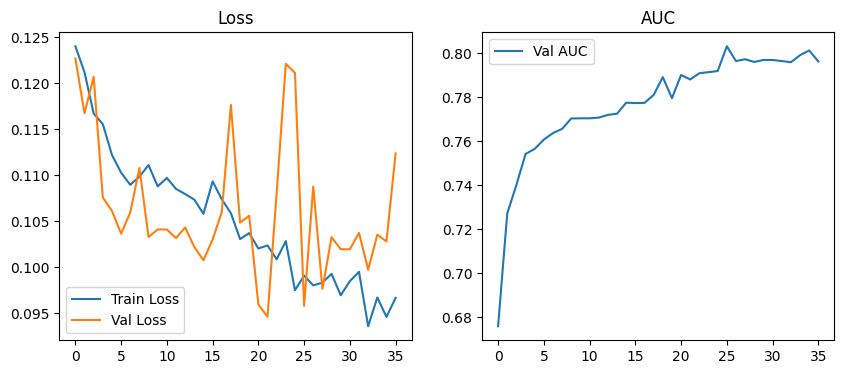

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 13. Evaluation on Validation Set

Final performance is computed on the full 500-image validation set using the best-checkpoint model:

- **ROC-AUC:** primary metric — measures the model's ability to rank positive samples above negative ones, independent of the decision threshold. An AUC of 1.0 is perfect; 0.5 is random.
- **Accuracy:** secondary metric, computed at the standard 0.5 threshold for interpretability
- **ROC curve:** visualizes the sensitivity (true positive rate) vs. 1-specificity (false positive rate) trade-off across all possible decision thresholds, useful for understanding clinical operating points

In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc

In [22]:
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.8031
Validation Accuracy: 0.7620


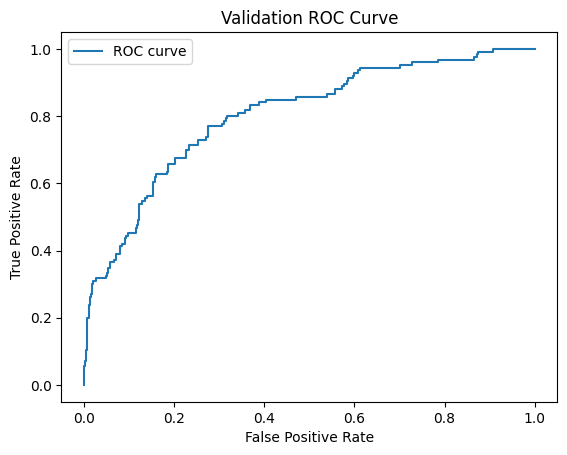

In [23]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 14. Test Set Predictions

The trained model generates probability scores for all 1000 test set images (labels unavailable). Raw logits are passed through `torch.sigmoid` to produce probabilities in [0, 1], which are saved to a CSV file. These individual model predictions will be combined with other models in the stacking ensemble to produce the final CodaBench submission.

In [24]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs)

test_outputs = predict(model, test_loader)

In [25]:
import csv

with open("resnet50_baseline.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])

In [26]:
with open("/content/drive/MyDrive/convx.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])